In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401


PROCESSED_PATH = "../data/processed"
FIGURES_PATH = "../figures"

In [33]:
# # LaTeX must be installed previously for this to work
plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
    }
)

FIGSIZE = (8, 4)

# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://seaborn.pydata.org/generated/seaborn.color_palette.html
palette = sns.color_palette("dark")
sns.set_palette(palette)
palette

[(0.0, 0.10980392156862745, 0.4980392156862745),
 (0.6941176470588235, 0.25098039215686274, 0.050980392156862744),
 (0.07058823529411765, 0.44313725490196076, 0.10980392156862745),
 (0.5490196078431373, 0.03137254901960784, 0.0),
 (0.34901960784313724, 0.11764705882352941, 0.44313725490196076),
 (0.34901960784313724, 0.1843137254901961, 0.050980392156862744),
 (0.6352941176470588, 0.20784313725490197, 0.5098039215686274),
 (0.23529411764705882, 0.23529411764705882, 0.23529411764705882),
 (0.7215686274509804, 0.5215686274509804, 0.0392156862745098),
 (0.0, 0.38823529411764707, 0.4549019607843137)]

In [34]:
original_df = pd.read_csv(f"{PROCESSED_PATH}/dataset.csv")
original_df["FECHA_OCURRENCIA"] = pd.to_datetime(original_df["FECHA_OCURRENCIA"])
df = pd.read_csv(f"{PROCESSED_PATH}/grouped.csv")

sorted_original_df = original_df.sort_values(by="FECHA_OCURRENCIA").reset_index(
    drop=True
)

display(
    original_df.head(),
    df.head(),
    (
        sorted_original_df.iloc[0]["FECHA_OCURRENCIA"],
        sorted_original_df.iloc[-1]["FECHA_OCURRENCIA"],
    ),

)

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


,AÑO,DIA,MES,DIA_SEMANA_OCURRENCIA,LOCALIDAD,GRAVEDAD,CLASE,CANTIDAD
0,2007,1,1,1,BOSA,CON HERIDOS,ATROPELLO,1
1,2007,1,1,1,BOSA,SOLO DANOS,CHOQUE,2
2,2007,1,1,1,CANDELARIA,SOLO DANOS,CHOQUE,1
3,2007,1,1,1,CHAPINERO,CON HERIDOS,CHOQUE,1
4,2007,1,1,1,CHAPINERO,CON HERIDOS,VOLCAMIENTO,1


(Timestamp('2007-01-01 00:00:00'), Timestamp('2017-09-29 22:20:00'))

In [35]:
bound_datetime = (
    sorted_original_df.iloc[0]["FECHA_OCURRENCIA"],
    sorted_original_df.iloc[-1]["FECHA_OCURRENCIA"],
)

localities_col = original_df["LOCALIDAD"].unique().tolist()

## Datetime related

### Grouped by years

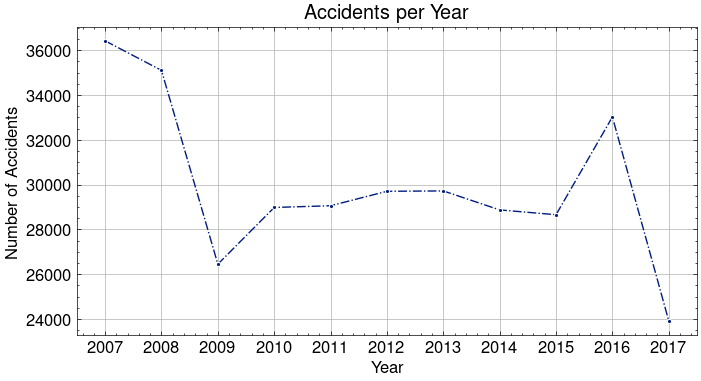

In [36]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(data=df.groupby("AÑO").sum().reset_index(), x="AÑO", y="CANTIDAD", marker="o", linestyle="-.", ax=ax)

ax.set(title="Accidents per Year", xlabel="Year", ylabel="Number of Accidents", xticks=df["AÑO"].unique())
ax.grid()

fig.savefig(f"{FIGURES_PATH}/accidents_per_year.pdf")
plt.show()

### Grouped by day of week

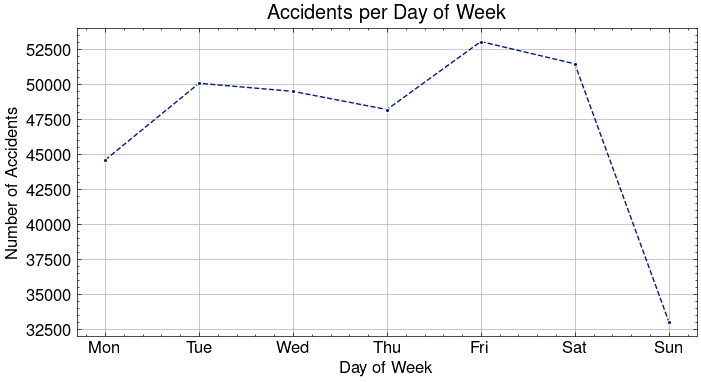

In [37]:
sub_df = df.groupby("DIA_SEMANA_OCURRENCIA").sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="DIA_SEMANA_OCURRENCIA",
    y="CANTIDAD",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Day of Week",
    ylabel="Number of Accidents",
)

ax.set_xticks(
    sorted(df["DIA_SEMANA_OCURRENCIA"].unique()),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)

ax.grid()

fig.savefig(f"{FIGURES_PATH}/accidents_per_day_of_week.pdf")
plt.show()

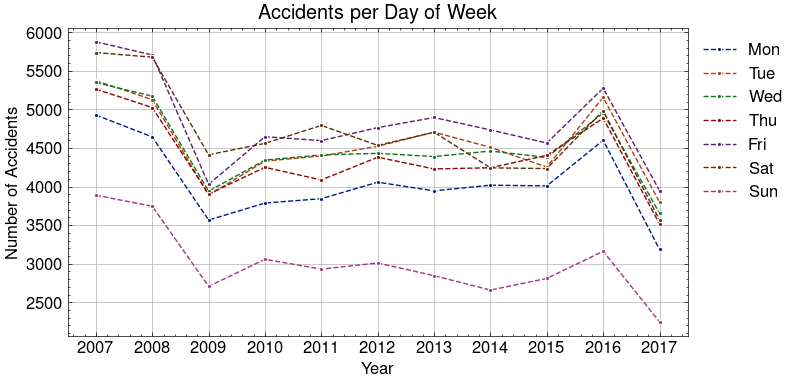

In [38]:
sub_df = df.groupby(["DIA_SEMANA_OCURRENCIA", "AÑO"]).sum().reset_index()
sub_df["DIA_SEMANA_OCURRENCIA"] = sub_df["DIA_SEMANA_OCURRENCIA"].replace({
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun",
})

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="AÑO",
    y="CANTIDAD",
    hue="DIA_SEMANA_OCURRENCIA",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Year",
    ylabel="Number of Accidents",
    xticks=df["AÑO"].unique(),
)

ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

fig.savefig(f"{FIGURES_PATH}/accidents_per_day_of_week_year.pdf")
plt.show()

### Grouped by month

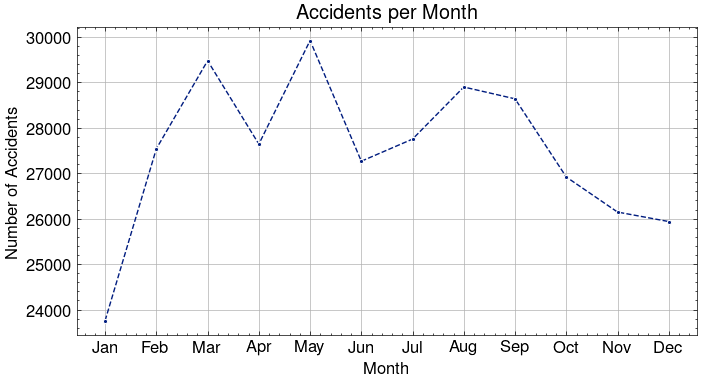

In [39]:
sub_df = df.groupby("MES").sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="MES",
    y="CANTIDAD",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Month",
    xlabel="Month",
    ylabel="Number of Accidents",
)

ax.set_xticks(
    sorted(df["MES"].unique()),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
)

ax.grid()

fig.savefig(f"{FIGURES_PATH}/accidents_per_month.pdf")
plt.show()

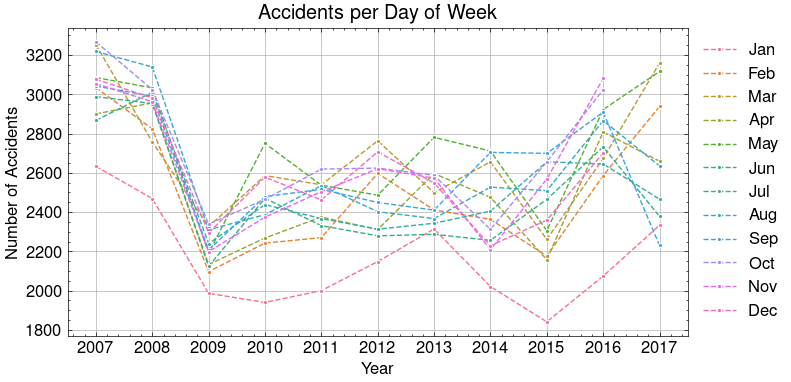

In [40]:
sub_df = df.groupby(["MES", "AÑO"]).sum().reset_index()
sub_df["MES"] = sub_df["MES"].replace({
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
})

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="AÑO",
    y="CANTIDAD",
    hue="MES",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Year",
    ylabel="Number of Accidents",
    xticks=df["AÑO"].unique(),
)

ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

fig.savefig(f"{FIGURES_PATH}/accidents_per_month_year.pdf")
plt.show()

### Group by all historic

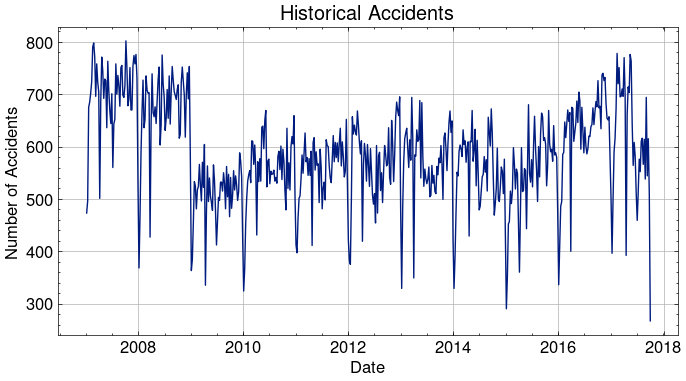

In [41]:
historical_df = original_df.set_index("FECHA_OCURRENCIA").resample("1W").size()
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.lineplot(data=historical_df, ax=ax)
ax.set(
    title="Historical Accidents",
    xlabel="Date",
    ylabel="Number of Accidents",
)

fig.savefig(f"{FIGURES_PATH}/historical_accidents.pdf")
plt.grid()
plt.show()

## Locality related

Hacer una sola está bastante complicado, joder. Tocará hacer varias e ir comparando uno a uno

### Historical


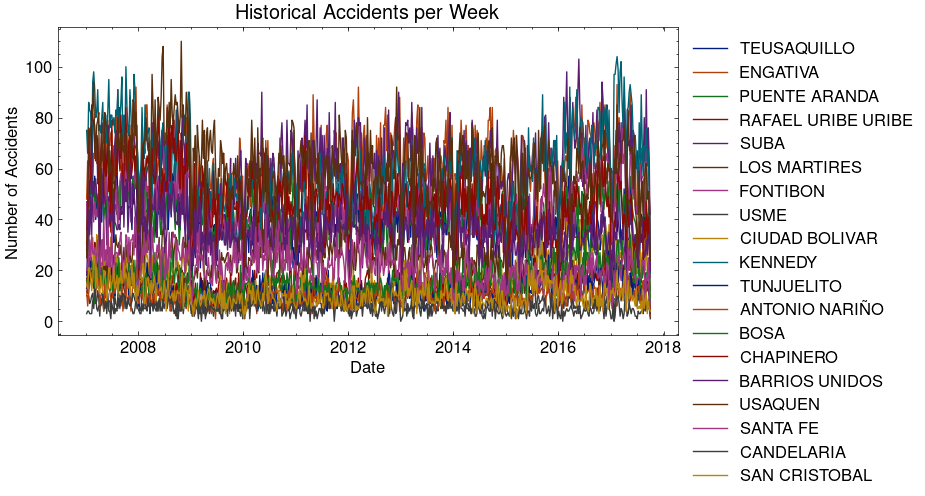

In [42]:
localities = {}
for locality in localities_col:
    localities[locality] = (
        original_df[original_df["LOCALIDAD"] == locality]
        .set_index("FECHA_OCURRENCIA")
        .resample("1W")
        .size()
    )

fig, ax = plt.subplots(figsize=FIGSIZE)

for locality, locality_df in localities.items():
    sns.lineplot(data=locality_df, ax=ax, label=locality)

ax.set(
    title="Historical Accidents per Week",
    xlabel="Date",
    ylabel="Number of Accidents",
)
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

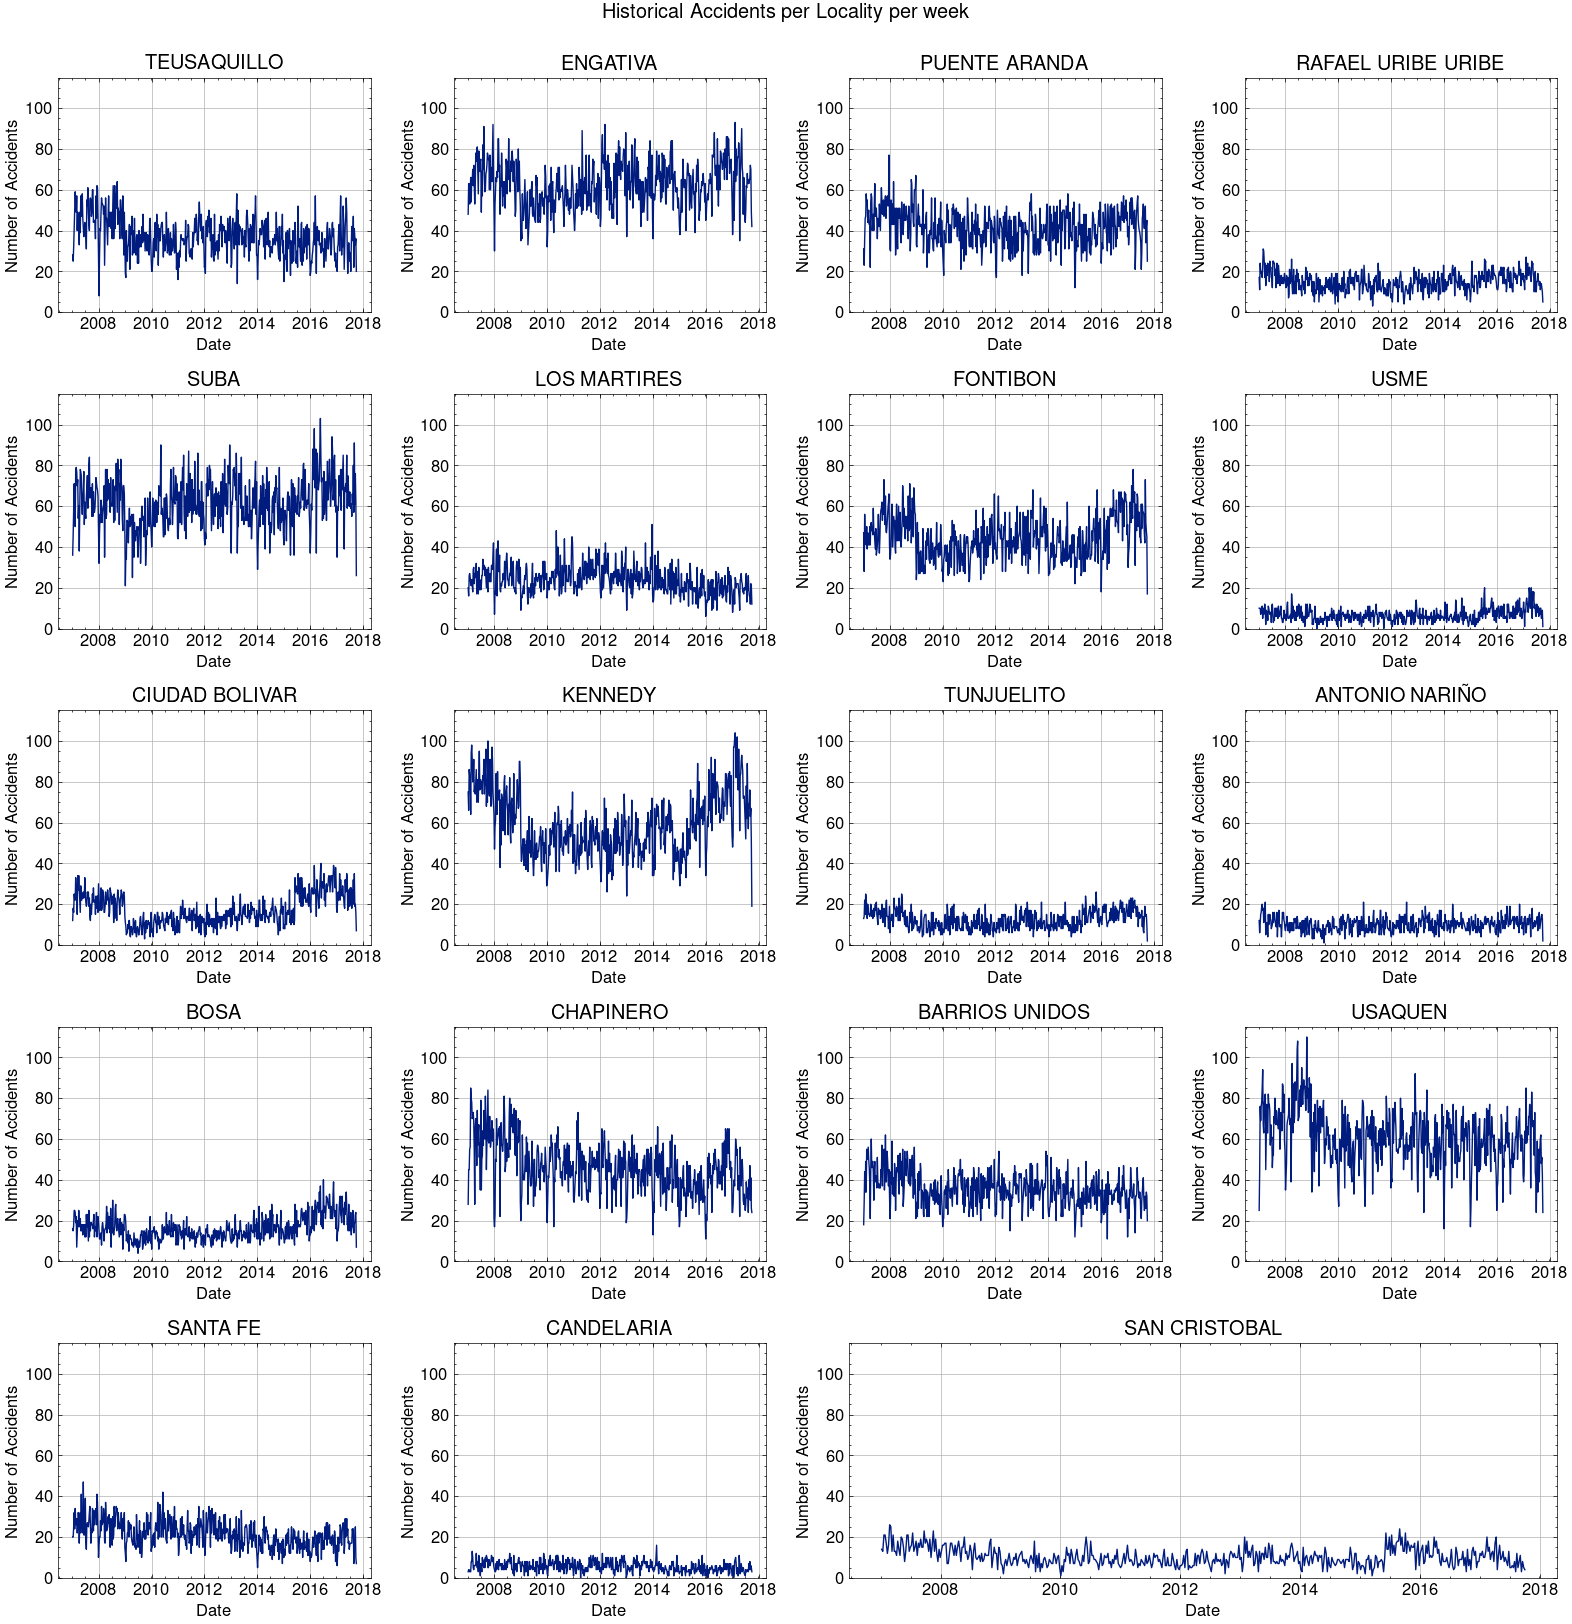

In [43]:
localities_col = original_df["LOCALIDAD"].unique().tolist()
localities = {}
for locality in localities_col:
    localities[locality] = (
        original_df[original_df["LOCALIDAD"] == locality]
        .set_index("FECHA_OCURRENCIA")
        .resample("1W")
        .size()
    )

locality_max = max(localities, key=lambda x: localities[x].max())
scale = localities[locality_max].max()

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(FIGSIZE[0] * 2, FIGSIZE[1] * 4))

# Para que no quede una cuadrícula vacía al final
# la concatenaré con la cuadrícula anterior
gs = axes[4, 2].get_gridspec()
for ax in axes[4, 2:]:
    ax.remove()

axbig = fig.add_subplot(gs[4, 2:])

for i, ((locality, locality_df), ax) in enumerate(
    zip(localities.items(), axes.flatten())
):
    if i >= 18:
        ax = axbig

    sns.lineplot(data=locality_df, ax=ax)
    ax.set(
        title=locality,
        xlabel="Date",
        ylabel="Number of Accidents",
        ylim=(0, scale + 5)
    )
    ax.grid()

fig.tight_layout()
fig.suptitle("Historical Accidents per Locality per week", y=1.02)
fig.savefig(f"{FIGURES_PATH}/historical_accidents_per_locality.pdf")
plt.show()

### Day of week

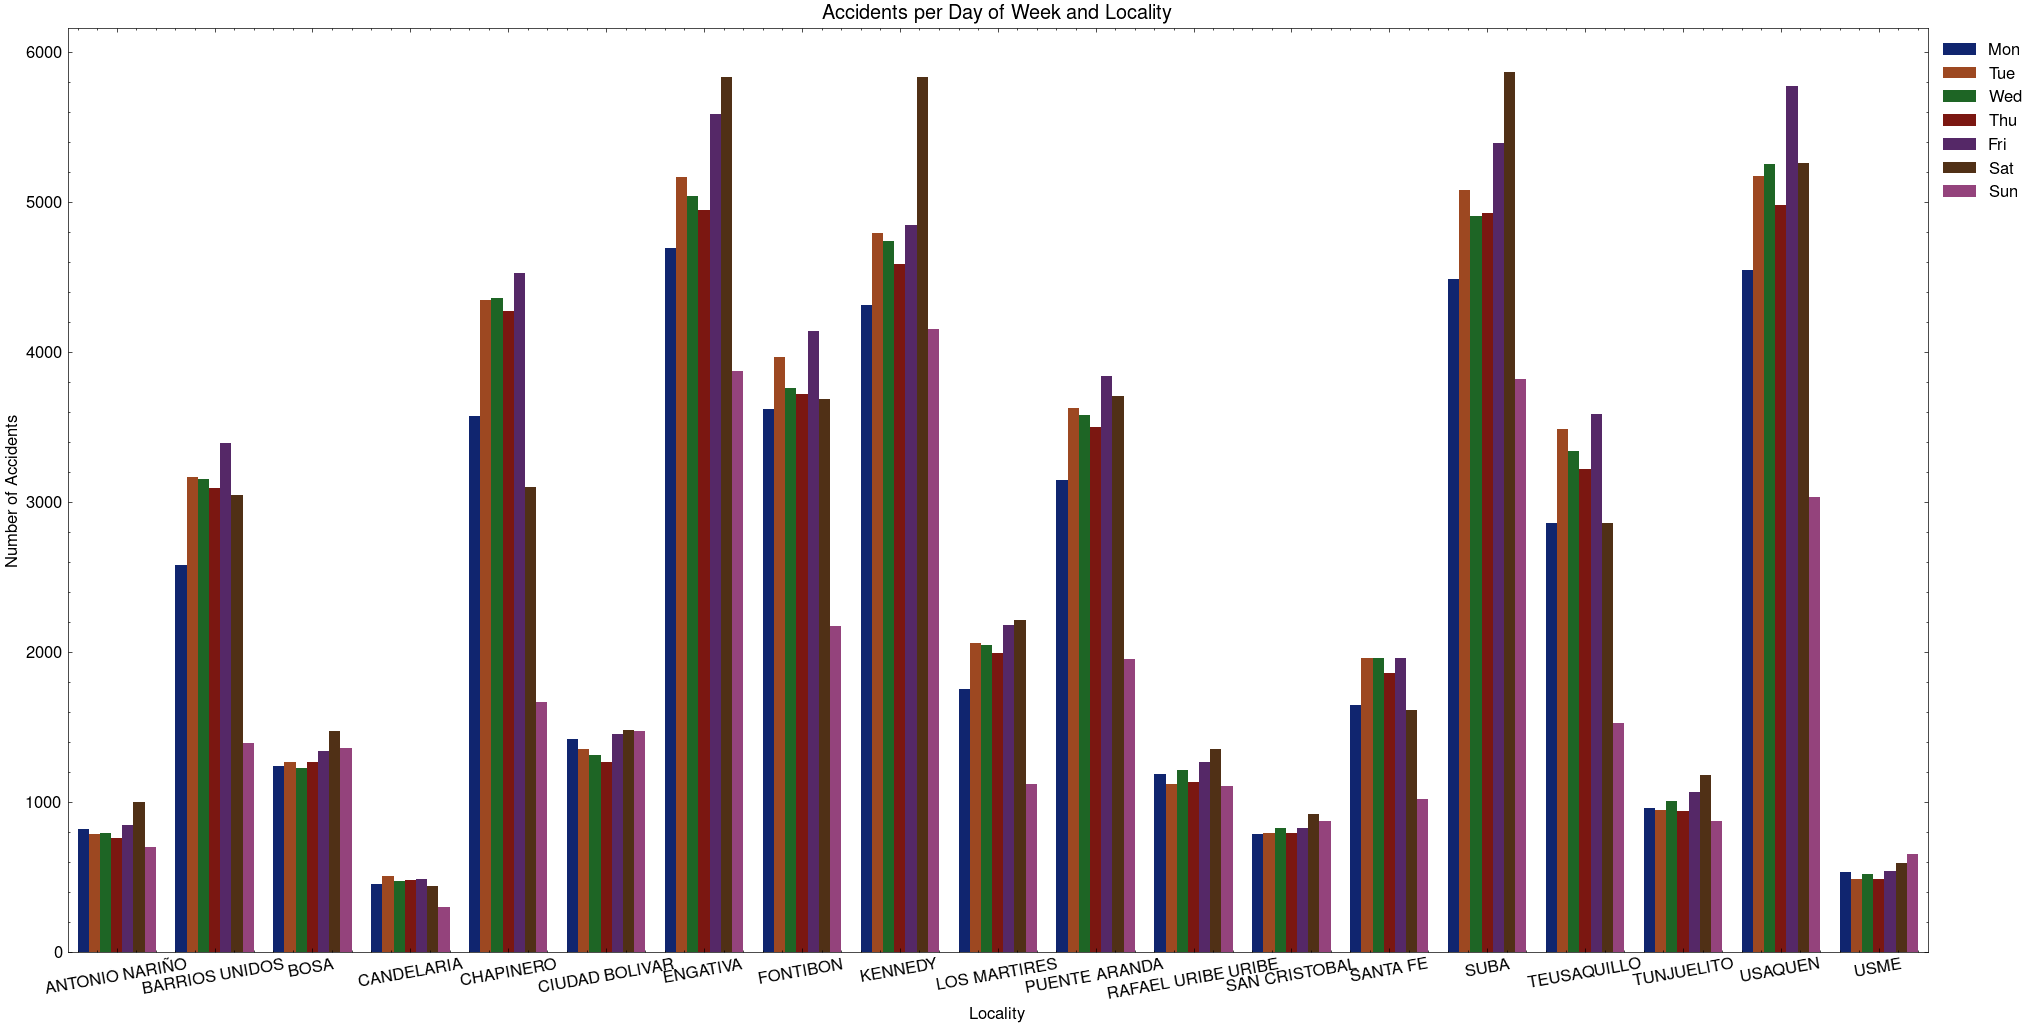

In [45]:
sub_df = df.groupby(["DIA_SEMANA_OCURRENCIA", "LOCALIDAD"]).sum().reset_index()
sub_df["DIA_SEMANA_OCURRENCIA"] = sub_df["DIA_SEMANA_OCURRENCIA"].replace({
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun",
})

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 3, FIGSIZE[1] * 3))

sns.barplot(
    data=sub_df,
    x="LOCALIDAD",
    y="CANTIDAD",
    hue="DIA_SEMANA_OCURRENCIA",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week and Locality",
    xlabel="Locality",
    ylabel="Number of Accidents",
)

plt.xticks(rotation=10, ha="center")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
fig.savefig(f"{FIGURES_PATH}/accidents_per_day_of_week_locality.pdf")
plt.show()